## Limpieza y procesamiento de datos para Datos Biométricos de un SmartWatch

### Integrantes:
- VINCENT FARENDEN CERON
- RODRIGO IGNACIO MARTINEZ BECKER
- DIEGO IGNACIO PENA Y LILLO LUHRS

### Asignatura:
- MACHINE LEARNING_001D

### Profesor:
- FRANCISCO JAVIER JEREZ SALAZAR

### Fecha:
- 13-09-2026

---

## Introducción y objetivo del informe

El presente informe técnico documenta el proceso de limpieza y preparación de un
conjunto de datos biométricos provenientes de un smartwatch. El objetivo es dejar
los datos correctamente representados y listos para su posterior uso en modelos de
Machine Learning.

El trabajo se desarrolla en Python, utilizando bibliotecas como **pandas**, **NumPy**,
**Matplotlib/Seaborn** y **Scikit-learn**, y se organiza en los siguientes apartados:

- Descripción general del conjunto de datos.
- Selección de características relevantes.
- Detección y gestión de valores faltantes y atípicos.
- Análisis de correlación entre variables.
- Escalamiento y codificación de variables.
- Conclusiones.

---

# Descripción general del conjunto de datos

Este dataset simula los registros biométricos capturados por un smartwatch. Cada fila
corresponde a una medición asociada a un usuario e incluye las siguientes variables:

| Variable | Descripción |
| --- | --- |
| ID de usuario | Identificador del portador del dispositivo. |
| Pulsaciones por minuto (BPM) | Frecuencia cardíaca registrada. |
| Nivel de oxígeno en sangre (%) | Saturación de oxígeno. |
| Contador de pasos | Cantidad de pasos registrados. |
| Duración del sueño (horas) | Horas dormidas. |
| Nivel de actividad | Categoría de actividad física (variable categórica). |
| Nivel de estrés | Indicador del estado de estrés. |

Los datos no están normalizados y presentan valores nulos, inconsistencias de
formato y valores atípicos, lo que justifica el proceso de limpieza descrito en este
informe.

### Carga del conjunto de datos

In [209]:
import pandas as pd
import numpy as np

RUTA_DATOS = "../data/raw/unclean_smartwatch_health_data.csv"

df = pd.read_csv(RUTA_DATOS)

df.head()

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,4174.0,58.939776,98.809650,5450.390578,7.167235622316564,Highly Active,1
1,NaN,NaN,98.532195,727.601610,6.538239375570314,Highly_Active,5
2,1860.0,247.803052,97.052954,2826.521994,ERROR,Highly Active,5
3,2294.0,40.000000,96.894213,13797.338044,7.367789630207228,Actve,3
4,2130.0,61.950165,98.583797,15679.067648,NaN,Highly_Active,6


### Dimensiones, tipos de datos y estadísticos descriptivos

#### Tipos de datos y valores faltantes

Se revisa el tipo asignado a cada columna junto con la cantidad de valores nulos, para
detectar variables que quedaron mal tipificadas.

In [210]:
resumen = pd.DataFrame({
    "Tipo de dato": df.dtypes.astype(str),
    "Dato no nulo": df.notna().sum(),
    "Dato nulo": df.isna().sum(),
    "% Datos nulos": (df.isna().mean() * 100).round(2),
    "Valores únicos": df.nunique(),
})

display(resumen)

,Tipo de dato,Dato no nulo,Dato nulo,% Datos nulos,Valores únicos
User ID,float64,9799,201,2.01,3634
Heart Rate (BPM),float64,9600,400,4.00,9517
Blood Oxygen Level (%),float64,9700,300,3.00,8175
Step Count,float64,9900,100,1.00,9900
Sleep Duration (hours),str,9850,150,1.50,9604
Activity Level,str,9800,200,2.00,6
Stress Level,str,9800,200,2.00,11


#### Estadísticos descriptivos

Se calculan los estadísticos de las variables numéricas (media, desviación estándar,
mínimo, cuartiles y máximo) y, por separado, el resumen de las variables de tipo texto.

In [211]:
display(df.describe().round(2))

display(df.describe(include="str"))

,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count
count,9799.00,9600.00,9700.00,9900.00
mean,3007.48,76.04,97.84,6985.69
std,1150.58,19.41,1.73,6885.81
min,1001.00,40.00,90.79,0.91
25%,1997.50,64.89,96.66,2021.04
50%,2998.00,75.22,98.01,4962.53
75%,4004.00,85.20,99.38,9724.90
max,4999.00,296.59,100.00,62486.69


,Sleep Duration (hours),Activity Level,Stress Level
count,9850,9800,9800
unique,9604,6,11
top,ERROR,Seddentary,2
freq,247,1676,1007


#### Categorías presentes en las variables de texto

Se listan los valores únicos de las columnas no numéricas para identificar
inconsistencias de escritura y valores que no corresponden a la variable.

In [212]:
def es_numero(valor):
    """Indica si un texto puede convertirse a numero."""
    try:
        float(valor)
        return True
    except ValueError:
        return False


for columna in df.select_dtypes(include="str").columns:
    valores = sorted(df[columna].dropna().unique().tolist())
    no_numericos = [v for v in valores if not es_numero(v)]

    if len(valores) <= 15:
        print(f"{columna} -> {len(valores)} categorías: {valores}")
    else:
        print(f"\n{columna} -> {len(valores)} valores únicos (mayormente numéricos)")
        print(f"   texto no numérico encontrado: {no_numericos}")
    print('\n')


Sleep Duration (hours) -> 9604 valores únicos (mayormente numéricos)
   texto no numérico encontrado: ['ERROR']


Activity Level -> 6 categorías: ['Active', 'Actve', 'Highly Active', 'Highly_Active', 'Seddentary', 'Sedentary']


Stress Level -> 11 categorías: ['1', '10', '2', '3', '4', '5', '6', '7', '8', '9', 'Very High']




---

# Selección de características relevantes

En este apartado se identifican las variables que aportan información útil para el
análisis y se descartan aquellas que no lo hacen. La decisión no se toma de forma
arbitraria: se evalúa cada columna según su rol dentro del fenómeno estudiado y según
métricas objetivas calculadas sobre el propio dataset.

### Criterios de selección

Se aplican cuatro criterios a cada variable:

| Criterio | Qué se evalúa | Regla de descarte |
| --- | --- | --- |
| **Rol semántico** | Si la variable describe el estado de salud del usuario o solo lo identifica. | Se descartan los identificadores, que no aportan información biométrica. |
| **Cardinalidad** | Proporción de valores únicos respecto al total de registros. | Una cardinalidad cercana al 100% en una variable no continua indica un identificador. |
| **Variabilidad** | Coeficiente de variación (desviación estándar / media). | Se descarta la variable con varianza nula o casi nula, porque no diferencia registros. |
| **Valores faltantes** | Porcentaje de nulos por columna. | Se descarta la variable con una proporción de nulos tan alta que la imputación deje de ser confiable (criterio habitual: sobre el 40%). |

### Conversión previa de las variables mal tipificadas

Para poder medir variabilidad es necesario que las columnas numéricas estén en un tipo
numérico. Como se detectó en el apartado anterior, `Sleep Duration (hours)` y
`Stress Level` quedaron como texto por contener los valores `"ERROR"` y `"Very High"`.

Se convierten con `pd.to_numeric(errors="coerce")`, lo que transforma esos textos no
válidos en `NaN`. **Esta conversión no elimina el problema**, solo lo hace visible como
valor faltante para tratarlo en el apartado siguiente.

In [213]:
df_eval = df.copy()

COLUMNAS_NUMERICAS_MAL_TIPIFICADAS = ["Sleep Duration (hours)", "Stress Level"]

for columna in COLUMNAS_NUMERICAS_MAL_TIPIFICADAS:
    nulos_antes = df_eval[columna].isna().sum()
    df_eval[columna] = pd.to_numeric(df_eval[columna], errors="coerce")
    nuevos_nulos = df_eval[columna].isna().sum() - nulos_antes

    print(f"{columna}: {nuevos_nulos} textos no validos convertidos a NaN")

display(df_eval.dtypes)

Sleep Duration (hours): 247 textos no validos convertidos a NaN
Stress Level: 49 textos no validos convertidos a NaN


User ID                   float64
Heart Rate (BPM)          float64
Blood Oxygen Level (%)    float64
Step Count                float64
Sleep Duration (hours)    float64
Activity Level                str
Stress Level              float64
dtype: object

### Evaluación de las características

Se construye una tabla con las métricas de los cuatro criterios para comparar todas las
columnas en igualdad de condiciones.

In [214]:
evaluacion = pd.DataFrame({
    "tipo": df_eval.dtypes.astype(str),
    "% nulos": (df_eval.isna().mean() * 100).round(2),
    "valores_unicos": df_eval.nunique(),
    "% cardinalidad": (df_eval.nunique() / len(df_eval) * 100).round(1),
    "desv_estandar": df_eval.std(numeric_only=True).round(2),
    "coef_variacion": (df_eval.std(numeric_only=True) / df_eval.mean(numeric_only=True)).round(3),
})

display(evaluacion)

display(df_eval.describe().round(2))

,tipo,% nulos,valores_unicos,% cardinalidad,desv_estandar,coef_variacion
Activity Level,str,2.00,6,0.1,NaN,NaN
Blood Oxygen Level (%),float64,3.00,8175,81.8,1.73,0.018
Heart Rate (BPM),float64,4.00,9517,95.2,19.41,0.255
Sleep Duration (hours),float64,3.97,9603,96.0,1.51,0.232
Step Count,float64,1.00,9900,99.0,6885.81,0.986
Stress Level,float64,2.49,10,0.1,2.87,0.526
User ID,float64,2.01,3634,36.3,1150.58,0.383


,User ID,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Stress Level
count,9799.00,9600.00,9700.00,9900.00,9603.00,9751.00
mean,3007.48,76.04,97.84,6985.69,6.51,5.46
std,1150.58,19.41,1.73,6885.81,1.51,2.87
min,1001.00,40.00,90.79,0.91,-0.19,1.00
25%,1997.50,64.89,96.66,2021.04,5.49,3.00
50%,2998.00,75.22,98.01,4962.53,6.50,5.00
75%,4004.00,85.20,99.38,9724.90,7.53,8.00
max,4999.00,296.59,100.00,62486.69,12.14,10.00


### Características seleccionadas y descartadas

De la evaluación anterior se desprende lo siguiente:

- **`User ID` se descarta.** Es un identificador administrativo del dispositivo, no una
  medición biométrica: su valor no describe el estado de salud del usuario y su magnitud
  numérica (media ≈ 3.007) carece de significado. Incluirlo llevaría al modelo a aprender
  relaciones inexistentes a partir de un número arbitrario.
- **Las seis variables restantes se retienen.** Todas son mediciones del dispositivo,
  presentan variabilidad suficiente (ninguna con varianza nula) y sus porcentajes de
  nulos van del 1,0% al 4,0%, muy por debajo del umbral de descarte, por lo que pueden
  recuperarse mediante imputación.

| Variable | Decisión | Justificación |
| --- | --- | --- |
| `User ID` | **Descartada** | Identificador sin valor predictivo; no es una medición biométrica. |
| `Heart Rate (BPM)` | Retenida | Indicador fisiológico central; alta variabilidad (CV 0,26). |
| `Blood Oxygen Level (%)` | Retenida | Indicador clínico relevante, aunque de rango estrecho (CV 0,02). |
| `Step Count` | Retenida | Refleja la actividad física real; la mayor dispersión del conjunto (CV 0,99). |
| `Sleep Duration (hours)` | Retenida | Variable clave del descanso; recuperable tras la limpieza. |
| `Activity Level` | Retenida | Única variable categórica; se codificará más adelante. |
| `Stress Level` | Retenida | Escala ordinal 1–10 asociada al bienestar del usuario. |

La decisión definitiva sobre posibles redundancias entre las variables retenidas se
revisa en el apartado de análisis de correlación.

In [215]:
COLUMNAS_DESCARTADAS = ["User ID"]

df_sel = df_eval.drop(columns=COLUMNAS_DESCARTADAS)

print(f"Columnas descartadas: {COLUMNAS_DESCARTADAS}")
print(f"Dimensiones antes:   {df_eval.shape}")
print(f"Dimensiones despues: {df_sel.shape}")

df_sel.head()

Columnas descartadas: ['User ID']
Dimensiones antes:   (10000, 7)
Dimensiones despues: (10000, 6)


,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,58.939776,98.809650,5450.390578,7.167236,Highly Active,1.0
1,NaN,98.532195,727.601610,6.538239,Highly_Active,5.0
2,247.803052,97.052954,2826.521994,NaN,Highly Active,5.0
3,40.000000,96.894213,13797.338044,7.367790,Actve,3.0
4,61.950165,98.583797,15679.067648,NaN,Highly_Active,6.0


---

# Detección y gestión de valores faltantes y atípicos

Este apartado aborda los tres problemas detectados en la exploración inicial:
categorías escritas de forma inconsistente, valores faltantes y valores atípicos. El
orden es importante: primero se unifican las categorías, luego se identifican los
valores imposibles (que pasan a ser faltantes) y solo al final se imputa, para no
propagar errores dentro de los propios estadísticos de imputación.

### Normalización de categorías inconsistentes

`Activity Level` presenta seis categorías para tres niveles reales, producto de errores
de escritura y de separadores distintos (`Actve`, `Seddentary`, `Highly_Active`). Se
unifican antes de cualquier otro tratamiento, porque de lo contrario la moda usada para
imputar se calcularía sobre categorías fragmentadas.

In [216]:
df_limpio = df_sel.copy()

EQUIVALENCIAS_ACTIVIDAD = {
    "Seddentary": "Sedentary",
    "Actve": "Active",
    "Highly_Active": "Highly Active",
}

print("Antes:", sorted(df_limpio["Activity Level"].dropna().unique().tolist()))

df_limpio["Activity Level"] = df_limpio["Activity Level"].replace(EQUIVALENCIAS_ACTIVIDAD)

print("Despues:", sorted(df_limpio["Activity Level"].dropna().unique().tolist()))

df_limpio["Activity Level"].value_counts(dropna=False)

Antes: ['Active', 'Actve', 'Highly Active', 'Highly_Active', 'Seddentary', 'Sedentary']
Despues: ['Active', 'Highly Active', 'Sedentary']


Activity Level
Sedentary        3333
Active           3265
Highly Active    3202
NaN               200
Name: count, dtype: int64

### Valores faltantes

Se cuantifican los nulos por columna. A los nulos originales del archivo se suman los
247 `"ERROR"` y los 49 `"Very High"` convertidos a `NaN` en el apartado anterior.

,nulos,% nulos
Heart Rate (BPM),400,4.00
Sleep Duration (hours),397,3.97
Blood Oxygen Level (%),300,3.00
Stress Level,249,2.49
Activity Level,200,2.00
Step Count,100,1.00


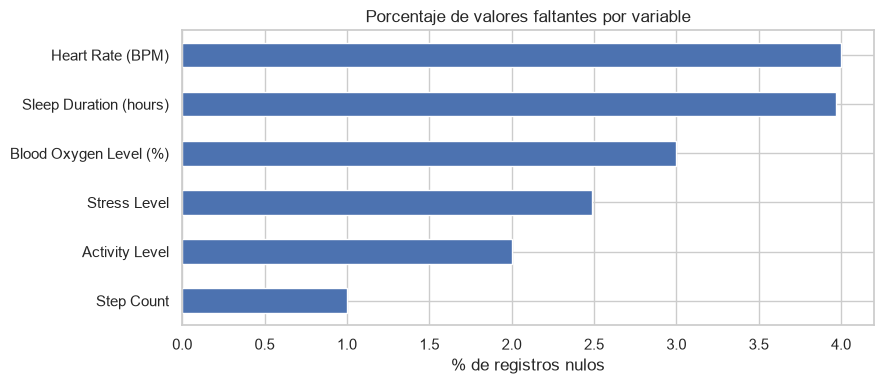

In [217]:
import matplotlib.pyplot as plt
import seaborn as sns

faltantes = pd.DataFrame({
    "nulos": df_limpio.isna().sum(),
    "% nulos": (df_limpio.isna().mean() * 100).round(2),
}).sort_values("% nulos", ascending=False)

display(faltantes)


sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(9, 4))
faltantes["% nulos"].plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("Porcentaje de valores faltantes por variable")
ax.set_xlabel("% de registros nulos")
ax.set_ylabel("")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Valores atípicos

La detección se realiza con el **rango intercuartílico (IQR)**, que define como atípico
todo valor fuera del intervalo `[Q1 - 1,5·IQR , Q3 + 1,5·IQR]`. Se prefiere esta técnica
sobre el z-score porque no asume normalidad y es robusta frente a los propios valores
extremos.

In [218]:
COLUMNAS_NUMERICAS = df_limpio.select_dtypes(include="number").columns.tolist()


def limites_iqr(serie, factor=1.5):
    """Devuelve los limites inferior y superior segun la regla del IQR."""
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - factor * iqr, q3 + factor * iqr


resumen_atipicos = []

for columna in COLUMNAS_NUMERICAS:
    inferior, superior = limites_iqr(df_limpio[columna])
    bajo = (df_limpio[columna] < inferior).sum()
    alto = (df_limpio[columna] > superior).sum()

    resumen_atipicos.append({
        "variable": columna,
        "limite_inferior": round(inferior, 2),
        "limite_superior": round(superior, 2),
        "minimo": round(df_limpio[columna].min(), 2),
        "maximo": round(df_limpio[columna].max(), 2),
        "atipicos_bajos": bajo,
        "atipicos_altos": alto,
        "% atipicos": round((bajo + alto) / len(df_limpio) * 100, 2),
    })

resumen_atipicos = pd.DataFrame(resumen_atipicos).set_index("variable")
resumen_atipicos

,limite_inferior,limite_superior,minimo,maximo,atipicos_bajos,atipicos_altos,% atipicos
variable,,,,,,,
Heart Rate (BPM),34.43,115.66,40.00,296.59,0,75,0.75
Blood Oxygen Level (%),92.59,103.45,90.79,100.00,30,0,0.30
Step Count,-9534.76,21280.70,0.91,62486.69,0,446,4.46
Sleep Duration (hours),2.44,10.58,-0.19,12.14,23,22,0.45
Stress Level,-4.50,15.50,1.00,10.00,0,0,0.00


Para leer los atípicos en contexto, cada variable numérica se grafica dos veces sobre el
mismo eje: arriba el **histograma**, que muestra dónde se concentra la masa de los datos
y qué tan asimétrica es la distribución, y abajo el **boxplot**, que marca los puntos que
la regla del IQR considera atípicos. Las líneas punteadas rojas son los límites
`Q1 - 1,5·IQR` y `Q3 + 1,5·IQR`, y la línea continua verde es la mediana.

Superponer ambas vistas evita una lectura apresurada: un punto fuera del bigote puede
ser un error del sensor, pero también la cola larga de una distribución asimétrica.

El último panel de la grilla corresponde a `Activity Level`. Al ser categórica no admite
histograma ni regla del IQR, por lo que se revisa con un gráfico de frecuencias que
muestra el reparto de los tres niveles una vez unificadas las etiquetas.

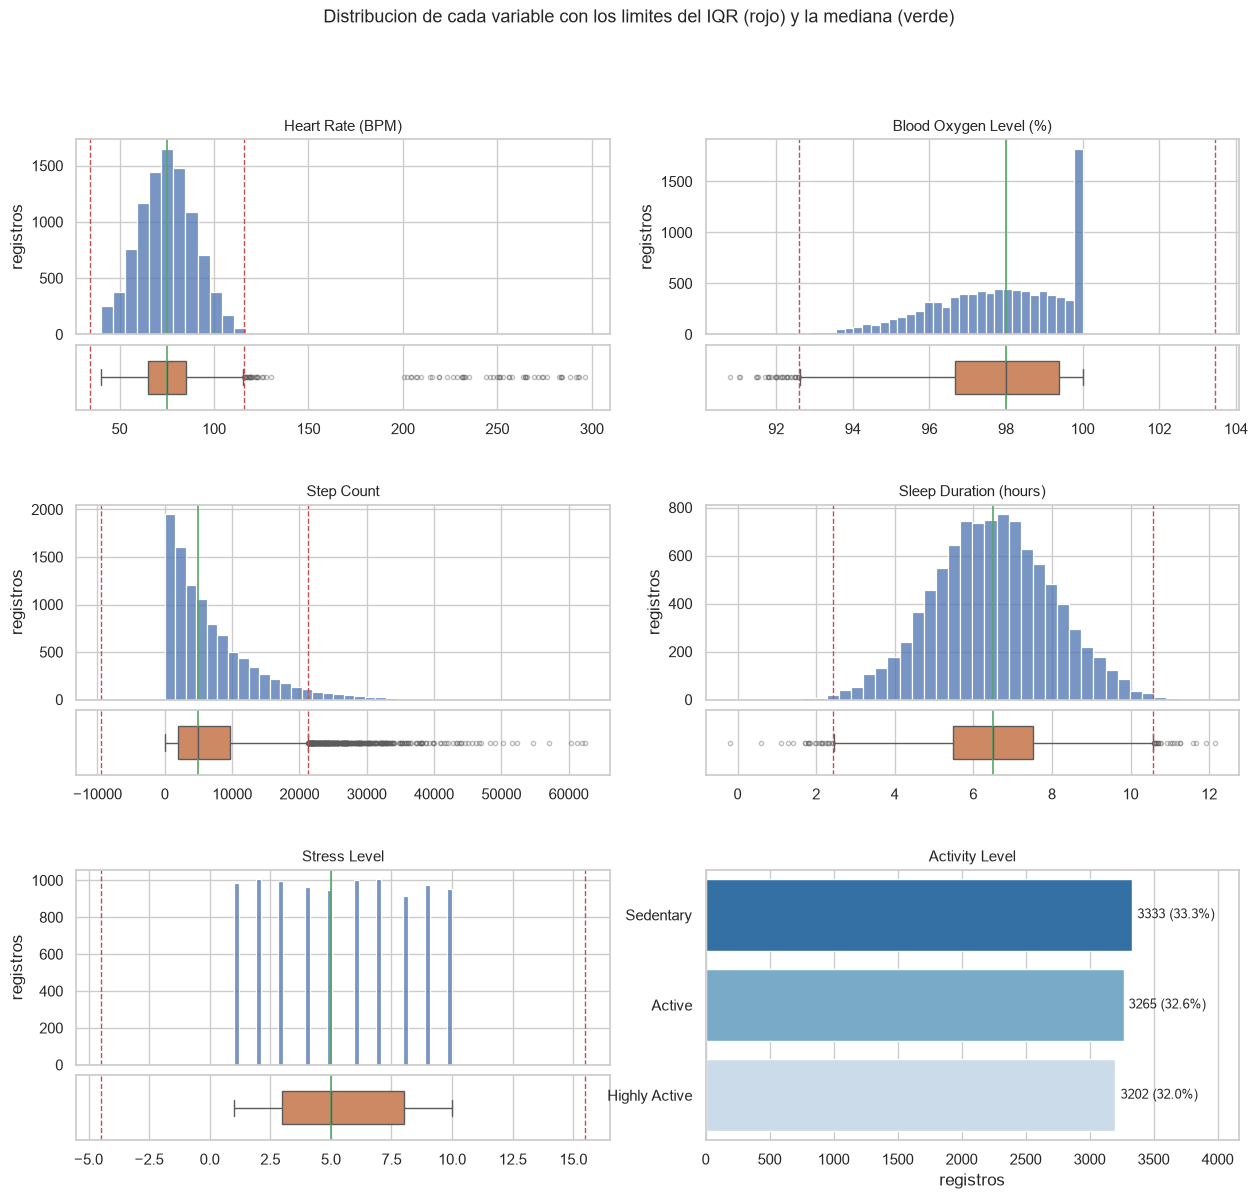

In [219]:
fig = plt.figure(figsize=(15, 13))
grilla = fig.add_gridspec(3, 2, hspace=0.35, wspace=0.18)

for indice, columna in enumerate(COLUMNAS_NUMERICAS):
    celda = grilla[indice // 2, indice % 2].subgridspec(2, 1, height_ratios=[3, 1],
                                                        hspace=0.08)
    ax_hist = fig.add_subplot(celda[0])
    ax_caja = fig.add_subplot(celda[1], sharex=ax_hist)
    inferior, superior = limites_iqr(df_limpio[columna])

    sns.histplot(df_limpio[columna].dropna(), bins=40, ax=ax_hist, color="#4c72b0")
    sns.boxplot(x=df_limpio[columna], ax=ax_caja, color="#dd8452", width=0.5,
                flierprops={"markersize": 3, "alpha": 0.4})

    for ax in (ax_hist, ax_caja):
        ax.axvline(inferior, color="#c44e52", linestyle="--", linewidth=1)
        ax.axvline(superior, color="#c44e52", linestyle="--", linewidth=1)
        ax.axvline(df_limpio[columna].median(), color="#55a868", linewidth=1.2)

    ax_hist.set_title(columna, fontsize=11)
    ax_hist.set_xlabel("")
    ax_hist.set_ylabel("registros")
    ax_hist.tick_params(labelbottom=False)
    ax_caja.set_xlabel("")

# Ultimo panel: la variable categorica, que no admite histograma ni IQR.
ax_actividad = fig.add_subplot(grilla[2, 1])

conteo = df_limpio["Activity Level"].value_counts().reindex(
    ["Sedentary", "Active", "Highly Active"]
)

sns.barplot(x=conteo.values, y=conteo.index, ax=ax_actividad, hue=conteo.index,
            palette="Blues_r", legend=False)

for posicion, valor in enumerate(conteo.values):
    ax_actividad.text(valor + 40, posicion,
                      f"{valor} ({valor / len(df_limpio) * 100:.1f}%)",
                      va="center", fontsize=9)

ax_actividad.set_title("Activity Level", fontsize=11)
ax_actividad.set_xlabel("registros")
ax_actividad.set_ylabel("")
ax_actividad.set_xlim(0, conteo.max() * 1.25)

fig.suptitle("Distribucion de cada variable con los limites del IQR (rojo) y la mediana (verde)",
             fontsize=13)
plt.show()

### Tratamiento de los valores atípicos

No todo valor atípico es un error: la regla del IQR también marca valores extremos que
son perfectamente posibles. Por eso cada caso se evalúa contra el rango fisiológicamente
plausible de la variable, y no solo contra el estadístico.

| Variable | Hallazgo | Decisión |
| --- | --- | --- |
| `Heart Rate (BPM)` | 50 registros sobre 200 bpm (máx. 296,6), imposibles de sostener. | **Corregir**: se marcan como `NaN` para imputarlos. |
| `Heart Rate (BPM)` | 84 registros con el valor exacto 40,0, que además es el mínimo de la columna. | **Corregir**: la repetición exacta en el borde indica un valor centinela del sensor, no una medición real. |
| `Sleep Duration (hours)` | 1 registro negativo (−0,19 h). | **Corregir**: una duración negativa es imposible. |
| `Blood Oxygen Level (%)` | 30 registros bajo 92,6% (mín. 90,8%). | **Retener**: corresponden a hipoxemia leve, clínicamente posible. |
| `Step Count` | 446 registros sobre el límite superior (máx. 62.487). | **Retener**: la variable es fuertemente asimétrica a la derecha; el IQR marca la asimetría, no errores. |
| `Stress Level` | Sin atípicos; la escala 1–10 acota el rango. | Sin acción. |

In [220]:
LIMITE_SUPERIOR_PULSO = 200
VALOR_CENTINELA_PULSO = 40.0

pulso_imposible = df_limpio["Heart Rate (BPM)"] > LIMITE_SUPERIOR_PULSO
pulso_centinela = df_limpio["Heart Rate (BPM)"] == VALOR_CENTINELA_PULSO
sueno_negativo = df_limpio["Sleep Duration (hours)"] < 0

print(f"Pulsaciones sobre {LIMITE_SUPERIOR_PULSO} bpm : {pulso_imposible.sum()}")
print(f"Pulsaciones centinela ({VALOR_CENTINELA_PULSO}): {pulso_centinela.sum()}")
print(f"Duracion de sueno negativa: {sueno_negativo.sum()}")

# Se guarda el estado previo y que registros se corrigen, para poder rendir
# cuenta despues de cada valor atipico detectado.
df_previo = df_limpio.copy()

MASCARAS_CORREGIDAS = {
    "Heart Rate (BPM)": pulso_imposible | pulso_centinela,
    "Sleep Duration (hours)": sueno_negativo,
}

df_limpio.loc[pulso_imposible | pulso_centinela, "Heart Rate (BPM)"] = np.nan
df_limpio.loc[sueno_negativo, "Sleep Duration (hours)"] = np.nan

print(f"\nNulos tras marcar los valores imposibles: {df_limpio.isna().sum().sum()}")

Pulsaciones sobre 200 bpm : 50
Pulsaciones centinela (40.0): 84
Duracion de sueno negativa: 1

Nulos tras marcar los valores imposibles: 1781


#### Qué pasa con los datos que quedan fuera del boxplot

Un punto fuera de los bigotes **no se elimina por el solo hecho de estar ahí**. La regla
del IQR es un criterio estadístico, no clínico: marca todo lo que se aleja del grueso de
los datos, incluida la cola legítima de una distribución asimétrica. Por eso en este
trabajo el atípico solo se corrige cuando además resulta **imposible en el mundo real**:

| Situación | Qué se hace | Por qué |
| --- | --- | --- |
| Atípico **y** fuera del rango fisiológico posible (pulso de 296 bpm, sueño de −0,19 h) | Se marca como `NaN` y se imputa con la mediana. | No es una medición sino un fallo de registro: mantenerlo desplazaría media, desviación y escalado. |
| Atípico **pero** posible (SpO₂ de 90,8%, 62.487 pasos, 118 bpm) | **Se conserva sin modificar.** | Es información real del usuario. Recortarla o eliminarla borraría justamente los casos extremos que suele interesar detectar. |
| Valor repetido exactamente en el borde (84 registros con 40,0 bpm) | Se trata como faltante, aunque el IQR no lo marque. | Que 84 mediciones independientes coincidan hasta el decimal delata un valor centinela del sensor, no una coincidencia. |

El criterio, entonces, es **corregir por implausibilidad, no por lejanía**. Ninguna fila
se elimina del dataset y ninguna variable se recorta o winsoriza. La celda siguiente
rinde cuenta de cada valor atípico detectado: cuántos se corrigieron, cuántos se
conservaron intactos y cuántos registros se descartaron.

In [221]:
balance = []

for columna in COLUMNAS_NUMERICAS:
    inferior, superior = limites_iqr(df_previo[columna])

    es_atipico = (df_previo[columna] < inferior) | (df_previo[columna] > superior)
    fue_corregido = MASCARAS_CORREGIDAS.get(columna, pd.Series(False, index=df_previo.index))

    balance.append({
        "variable": columna,
        "atipicos_detectados": int(es_atipico.sum()),
        "atipicos_corregidos": int((es_atipico & fue_corregido).sum()),
        "atipicos_retenidos": int((es_atipico & ~fue_corregido).sum()),
        "corregidos_no_atipicos": int((~es_atipico & fue_corregido).sum()),
        "filas_eliminadas": 0,
    })

balance = pd.DataFrame(balance).set_index("variable")

print(f"Atipicos detectados por el IQR : {balance['atipicos_detectados'].sum()}")
print(f"   corregidos por implausibles : {balance['atipicos_corregidos'].sum()}")
print(f"   retenidos sin modificar     : {balance['atipicos_retenidos'].sum()}")
print(f"Valores centinela corregidos que el IQR no marcaba: "
      f"{balance['corregidos_no_atipicos'].sum()}")
print(f"Filas eliminadas del dataset   : {balance['filas_eliminadas'].sum()}\n")

balance

Atipicos detectados por el IQR : 596
   corregidos por implausibles : 51
   retenidos sin modificar     : 545
Valores centinela corregidos que el IQR no marcaba: 84
Filas eliminadas del dataset   : 0



,atipicos_detectados,atipicos_corregidos,atipicos_retenidos,corregidos_no_atipicos,filas_eliminadas
variable,,,,,
Heart Rate (BPM),75,50,25,84,0
Blood Oxygen Level (%),30,0,30,0,0
Step Count,446,0,446,0,0
Sleep Duration (hours),45,1,44,0,0
Stress Level,0,0,0,0,0


### Estrategia de imputación

Ninguna variable supera el 5% de valores faltantes, por lo que eliminar los registros
afectados implicaría perder alrededor de un 15% del dataset sin necesidad. Se opta por
imputar:

- **Variables numéricas continuas → mediana.** Es robusta frente a la asimetría de
  `Step Count` y a los valores extremos que se decidió retener; la media quedaría
  desplazada por ellos.
- **`Stress Level` → mediana redondeada.** Es una escala ordinal entera de 1 a 10, por
  lo que el valor imputado debe ser también un entero de esa escala.
- **`Activity Level` → moda.** Al ser categórica no admite un promedio; se usa la
  categoría más frecuente, ya unificada en el paso anterior.

In [222]:
COLUMNAS_CONTINUAS = [
    "Heart Rate (BPM)",
    "Blood Oxygen Level (%)",
    "Step Count",
    "Sleep Duration (hours)",
]

registro_imputacion = []

for columna in COLUMNAS_CONTINUAS:
    valor = df_limpio[columna].median()
    nulos = df_limpio[columna].isna().sum()
    df_limpio[columna] = df_limpio[columna].fillna(valor)
    registro_imputacion.append({"variable": columna, "estrategia": "mediana",
                                "valor_imputado": round(valor, 2), "registros": nulos})

valor = round(df_limpio["Stress Level"].median())
nulos = df_limpio["Stress Level"].isna().sum()
df_limpio["Stress Level"] = df_limpio["Stress Level"].fillna(valor).astype(int)
registro_imputacion.append({"variable": "Stress Level", "estrategia": "mediana redondeada",
                            "valor_imputado": valor, "registros": nulos})

valor = df_limpio["Activity Level"].mode()[0]
nulos = df_limpio["Activity Level"].isna().sum()
df_limpio["Activity Level"] = df_limpio["Activity Level"].fillna(valor)
registro_imputacion.append({"variable": "Activity Level", "estrategia": "moda",
                            "valor_imputado": valor, "registros": nulos})

pd.DataFrame(registro_imputacion).set_index("variable")

,estrategia,valor_imputado,registros
variable,,,
Heart Rate (BPM),mediana,75.27,534
Blood Oxygen Level (%),mediana,98.01,300
Step Count,mediana,4962.53,100
Sleep Duration (hours),mediana,6.5,398
Stress Level,mediana redondeada,5,249
Activity Level,moda,Sedentary,200


### Verificación del resultado

Se comprueba que no queden valores faltantes y se comparan las distribuciones con las
del inicio del apartado.

Valores nulos restantes: 0
Dimensiones del dataset limpio: (10000, 6)


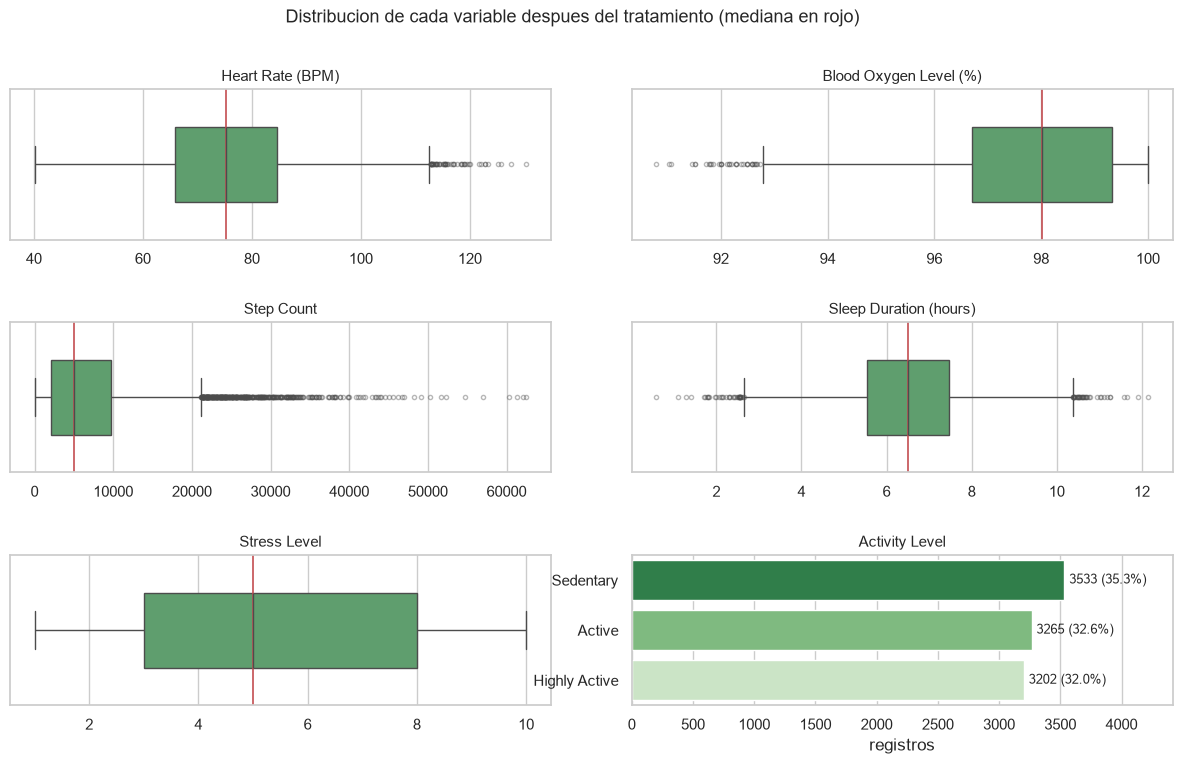

,count,mean,std,min,25%,50%,75%,max
Heart Rate (BPM),10000.0,75.43,14.07,40.12,65.80,75.27,84.58,130.31
Blood Oxygen Level (%),10000.0,97.85,1.71,90.79,96.70,98.01,99.33,100.00
Step Count,10000.0,6965.45,6854.25,0.91,2037.30,4962.53,9680.10,62486.69
Sleep Duration (hours),10000.0,6.51,1.48,0.59,5.54,6.50,7.48,12.14
Stress Level,10000.0,5.45,2.84,1.00,3.00,5.00,8.00,10.00


In [223]:
print(f"Valores nulos restantes: {df_limpio.isna().sum().sum()}")
print(f"Dimensiones del dataset limpio: {df_limpio.shape}")

fig = plt.figure(figsize=(15, 8))
grilla = fig.add_gridspec(3, 2, hspace=0.55, wspace=0.15)

for indice, columna in enumerate(COLUMNAS_NUMERICAS):
    ax = fig.add_subplot(grilla[indice // 2, indice % 2])

    sns.boxplot(x=df_limpio[columna], ax=ax, color="#55a868", width=0.5,
                flierprops={"markersize": 3, "alpha": 0.4})

    ax.axvline(df_limpio[columna].median(), color="#c44e52", linewidth=1.2)
    ax.set_title(columna, fontsize=11)
    ax.set_xlabel("")

# Ultimo panel: la categorica, ya imputada con la moda.
ax_actividad = fig.add_subplot(grilla[2, 1])

conteo = df_limpio["Activity Level"].value_counts().reindex(
    ["Sedentary", "Active", "Highly Active"]
)

sns.barplot(x=conteo.values, y=conteo.index, ax=ax_actividad, hue=conteo.index,
            palette="Greens_r", legend=False)

for posicion, valor in enumerate(conteo.values):
    ax_actividad.text(valor + 40, posicion,
                      f"{valor} ({valor / len(df_limpio) * 100:.1f}%)",
                      va="center", fontsize=9)

ax_actividad.set_title("Activity Level", fontsize=11)
ax_actividad.set_xlabel("registros")
ax_actividad.set_ylabel("")
ax_actividad.set_xlim(0, conteo.max() * 1.25)

fig.suptitle("Distribucion de cada variable despues del tratamiento (mediana en rojo)",
             fontsize=13)
plt.show()

df_limpio.describe().T.round(2)

---

# Análisis de correlación entre variables

Con el dataset ya limpio se estudia la relación entre las variables numéricas, con dos
objetivos: identificar redundancia —dos variables que miden lo mismo aportan información
duplicada al modelo— y describir el comportamiento conjunto de las mediciones.

### Matriz de correlación

Se emplea el coeficiente de **Pearson** para las variables continuas y se acompaña con
**Spearman**, que al basarse en rangos resulta más adecuado para `Stress Level`, que es
ordinal, y para `Step Count`, que es asimétrica.

,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Stress Level
Heart Rate (BPM),1.000,-0.005,0.001,-0.007,-0.001
Blood Oxygen Level (%),-0.005,1.000,-0.005,-0.001,-0.009
Step Count,0.001,-0.005,1.000,0.008,0.006
Sleep Duration (hours),-0.007,-0.001,0.008,1.000,0.004
Stress Level,-0.001,-0.009,0.006,0.004,1.000


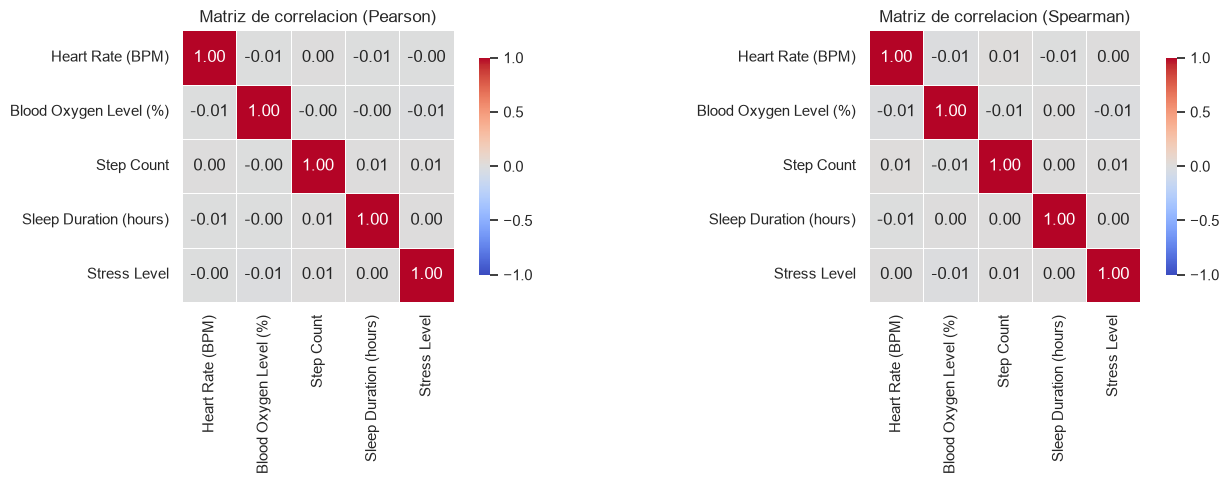

Pares de variables ordenados por correlacion absoluta:

Blood Oxygen Level (%)  Stress Level             -0.009
Step Count              Sleep Duration (hours)    0.008
Heart Rate (BPM)        Sleep Duration (hours)   -0.007
Step Count              Stress Level              0.006
Heart Rate (BPM)        Blood Oxygen Level (%)   -0.005
Blood Oxygen Level (%)  Step Count               -0.005
Sleep Duration (hours)  Stress Level              0.004
Heart Rate (BPM)        Step Count                0.001
                        Stress Level             -0.001
Blood Oxygen Level (%)  Sleep Duration (hours)   -0.001

Pares con correlacion absoluta mayor a 0.8: 0


In [224]:
correlacion_pearson = df_limpio[COLUMNAS_NUMERICAS].corr(method="pearson")
correlacion_spearman = df_limpio[COLUMNAS_NUMERICAS].corr(method="spearman")

display(correlacion_pearson.round(3))







fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (titulo, matriz) in zip(axes, [("Pearson", correlacion_pearson),
                                       ("Spearman", correlacion_spearman)]):
    sns.heatmap(matriz, annot=True, fmt=".2f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax,
                cbar_kws={"shrink": 0.8})
    ax.set_title(f"Matriz de correlacion ({titulo})")

plt.tight_layout()
plt.show()





UMBRAL_REDUNDANCIA = 0.8

pares = (
    correlacion_pearson
    .where(np.triu(np.ones(correlacion_pearson.shape), k=1).astype(bool))
    .stack()
    .dropna()
    .sort_values(key=abs, ascending=False)
)

print("Pares de variables ordenados por correlacion absoluta:\n")
print(pares.round(3).to_string())

redundantes = pares[abs(pares) > UMBRAL_REDUNDANCIA]
print(f"\nPares con correlacion absoluta mayor a {UMBRAL_REDUNDANCIA}: {len(redundantes)}")

### Interpretación de las correlaciones

Los coeficientes obtenidos son todos cercanos a cero, tanto en Pearson como en Spearman.
Esto significa que **no existe dependencia lineal ni monótona apreciable entre las
mediciones**: conocer el pulso de un registro no permite anticipar sus pasos, su
saturación de oxígeno ni sus horas de sueño.

Es un resultado coherente con el origen del conjunto de datos, que es una simulación en
la que cada variable fue generada de forma independiente. En un dataset real cabría
esperar, por ejemplo, una relación negativa entre el nivel de estrés y la duración del
sueño.

### Eliminación o retención de características

Ningún par supera el umbral de redundancia de 0,8 fijado como criterio, por lo que **no
se elimina ninguna variable adicional en este apartado**. Cada característica aporta
información propia y no duplicada, y el conjunto seleccionado se mantiene tal como quedó
tras el apartado de selección.

---

# Escalamiento y codificación de variables

Los algoritmos de Machine Learning trabajan con valores numéricos y son sensibles a la
escala de las variables. En el dataset actual `Step Count` se mueve en miles de unidades
mientras que `Blood Oxygen Level (%)` lo hace en torno a 98, de modo que sin escalar la
primera dominaría cualquier cálculo basado en distancias.

### Codificación de variables categóricas

`Activity Level` es la única variable categórica y sus tres niveles tienen un **orden
natural** (`Sedentary` < `Active` < `Highly Active`). Por eso se aplica una codificación
**ordinal** con `OrdinalEncoder`, que preserva esa jerarquía en un solo campo. Un
One-Hot Encoding sería preferible en una variable nominal, pero aquí desperdiciaría la
información de orden y añadiría columnas innecesarias.

`Stress Level` ya es una escala ordinal numérica de 1 a 10, por lo que no requiere
codificación.

In [225]:
from sklearn.preprocessing import OrdinalEncoder

ORDEN_ACTIVIDAD = ["Sedentary", "Active", "Highly Active"]

df_final = df_limpio.copy()

codificador = OrdinalEncoder(categories=[ORDEN_ACTIVIDAD])
df_final["Activity Level"] = codificador.fit_transform(df_final[["Activity Level"]]).astype(int)

print("Codificacion aplicada:")
for posicion, categoria in enumerate(ORDEN_ACTIVIDAD):
    print(f"  {categoria:<15} -> {posicion}")

df_final["Activity Level"].value_counts().sort_index()

Codificacion aplicada:
  Sedentary       -> 0
  Active          -> 1
  Highly Active   -> 2


Activity Level
0    3533
1    3265
2    3202
Name: count, dtype: int64

### Escalamiento de variables numéricas

Se aplican dos técnicas según la naturaleza de cada variable:

- **Estandarización (Z-score)** a las cuatro variables continuas. Las deja con media 0 y
  desviación estándar 1 y, a diferencia de la normalización Min-Max, no se ve arrastrada
  por los valores extremos de `Step Count` que se decidió retener.
- **Normalización Min-Max** a las dos variables ordinales (`Activity Level` y
  `Stress Level`). Sus escalas son acotadas y conocidas, por lo que llevarlas al rango
  `[0, 1]` conserva el orden y las deja comparables con el resto.

In [226]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

COLUMNAS_ORDINALES = ["Activity Level", "Stress Level"]

estandarizador = StandardScaler()
normalizador = MinMaxScaler()

df_final[COLUMNAS_CONTINUAS] = estandarizador.fit_transform(df_final[COLUMNAS_CONTINUAS])
df_final[COLUMNAS_ORDINALES] = normalizador.fit_transform(df_final[COLUMNAS_ORDINALES])

df_final.describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
Heart Rate (BPM),10000.0,-0.000,1.000,-2.510,-0.685,-0.012,0.650,3.901
Blood Oxygen Level (%),10000.0,0.000,1.000,-4.134,-0.670,0.096,0.868,1.262
Step Count,10000.0,0.000,1.000,-1.016,-0.719,-0.292,0.396,8.101
Sleep Duration (hours),10000.0,-0.000,1.000,-4.002,-0.652,-0.002,0.656,3.812
Activity Level,10000.0,0.483,0.410,0.000,0.000,0.500,1.000,1.000
Stress Level,10000.0,0.495,0.315,0.000,0.222,0.444,0.778,1.000


### Dataset final

El conjunto resultante no tiene valores faltantes, sus categorías están unificadas y
codificadas, y todas sus variables se encuentran en escalas comparables.

In [227]:
print(f"Dimensiones : {df_final.shape}")
print(f"Nulos       : {df_final.isna().sum().sum()}")

df_final.head()

Dimensiones : (10000, 6)
Nulos       : 0


,Heart Rate (BPM),Blood Oxygen Level (%),Step Count,Sleep Duration (hours),Activity Level,Stress Level
0,-1.172624,0.564203,-0.221051,0.447302,1.0,0.000000
1,-0.012033,0.401647,-0.910117,0.021774,1.0,0.444444
2,-0.012033,-0.465014,-0.603879,-0.001753,1.0,0.444444
3,-0.012033,-0.558017,0.996787,0.582980,0.5,0.222222
4,-0.958618,0.431880,1.271336,-0.001753,1.0,0.555556


### Exportación de los datos procesados

Se guardan dos versiones en `data/processed/`, porque cada una responde a un uso
distinto:

- **`smartwatch_health_data_clean.csv`**: datos limpios pero en sus unidades originales
  (bpm, pasos, horas). Es la versión legible, útil para el análisis descriptivo y para
  verificar el resultado de la limpieza.
- **`smartwatch_health_data_model.csv`**: la misma información ya codificada y escalada,
  lista para alimentar un modelo.

In [228]:
from pathlib import Path

RUTA_PROCESADOS = Path("../data/processed")
RUTA_PROCESADOS.mkdir(parents=True, exist_ok=True)

ARCHIVO_LIMPIO = RUTA_PROCESADOS / "smartwatch_health_data_clean.csv"
ARCHIVO_MODELO = RUTA_PROCESADOS / "smartwatch_health_data_model.csv"

df_limpio.to_csv(ARCHIVO_LIMPIO, index=False)
df_final.to_csv(ARCHIVO_MODELO, index=False)

for archivo in (ARCHIVO_LIMPIO, ARCHIVO_MODELO):
    print(f"{archivo.name:<40} {archivo.stat().st_size / 1024:6.1f} KB")

smartwatch_health_data_clean.csv          815.3 KB
smartwatch_health_data_model.csv          976.1 KB


---

# Comparación final: datos originales y datos procesados

Para cerrar el trabajo se contrasta el punto de partida con el resultado. La comparación
se hace contra `df_sel`, es decir, los datos tal como venían del archivo (con sus nulos,
sus categorías mal escritas y sus valores imposibles), y no contra la versión escalada,
de modo que ambas series estén en las mismas unidades y las diferencias que se vean sean
efecto de la limpieza y no del cambio de escala.

Cada panel superpone el histograma original (gris) y el procesado (azul), con las
medianas de ambos marcadas con líneas verticales. Las variables cuyos atípicos se
decidió retener deberían mostrar dos curvas prácticamente idénticas; las que tenían
valores imposibles, un recorte visible en la cola.

El último panel corresponde a `Activity Level`: al ser categórica se compara con un
gráfico de frecuencias, donde se ve cómo las seis etiquetas originales se consolidan en
los tres niveles reales sin perder registros.

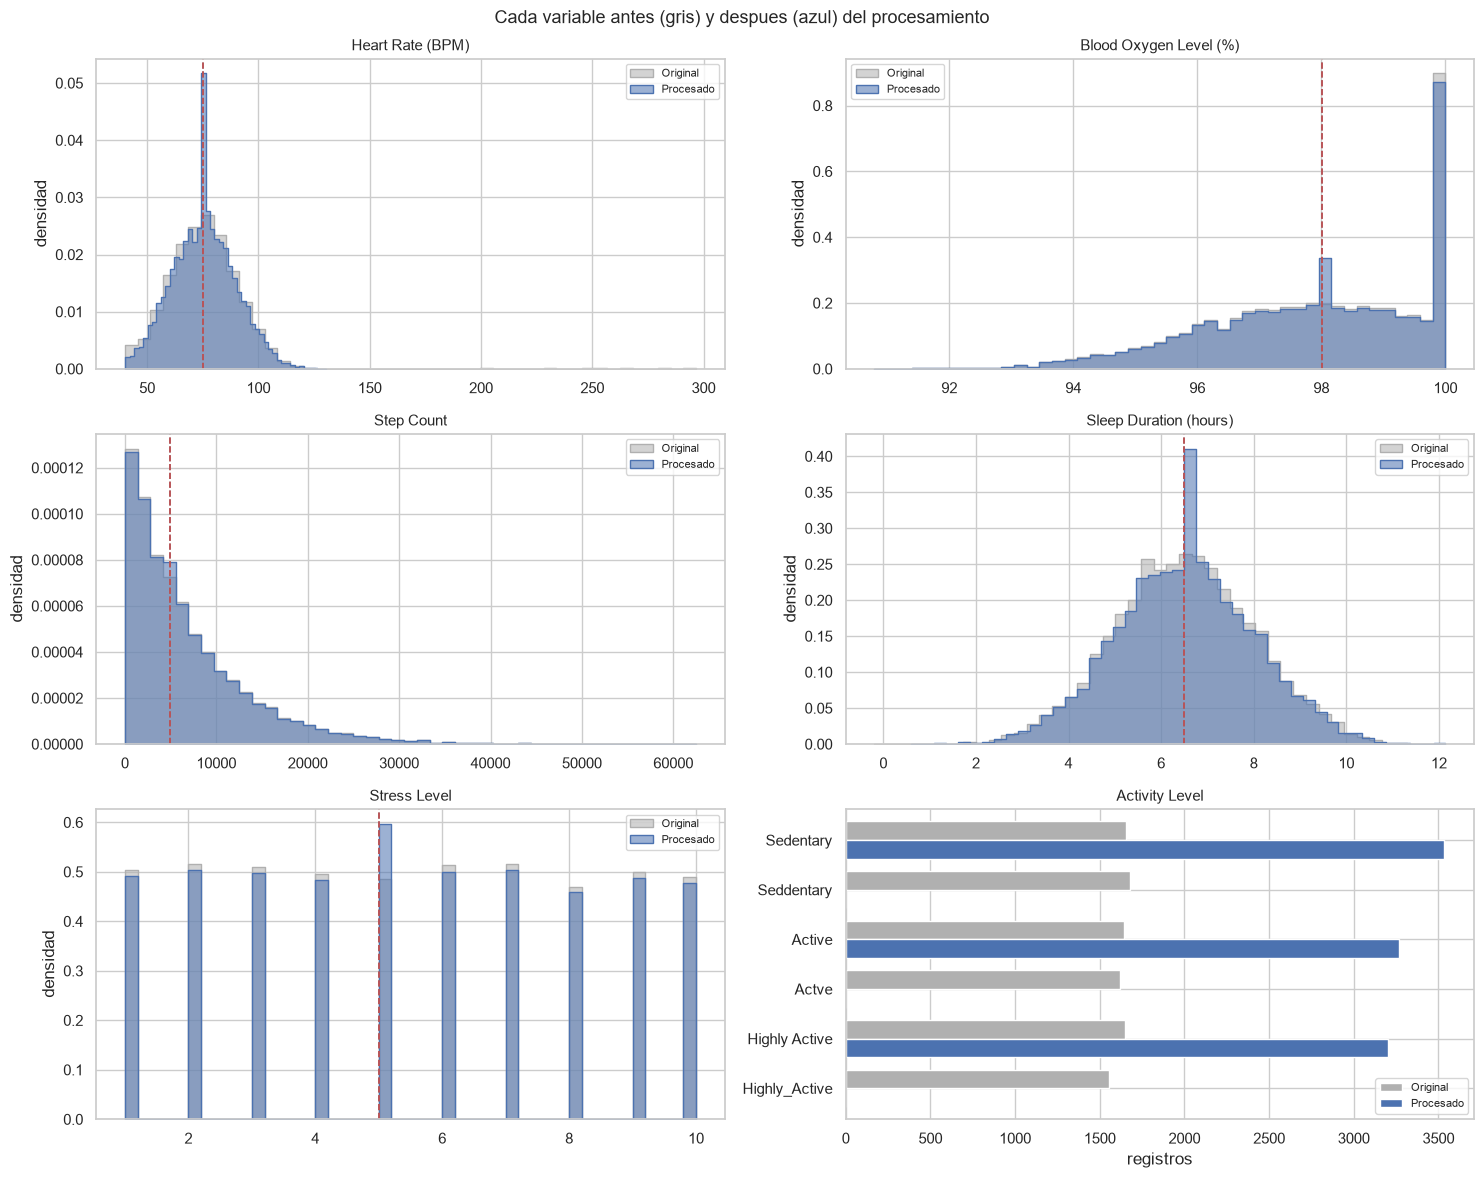

In [229]:
fig, axes = plt.subplots(3, 2, figsize=(15, 12))

for ax, columna in zip(axes.flat, COLUMNAS_NUMERICAS):
    sns.histplot(df_sel[columna].dropna(), bins=45, ax=ax, color="#b0b0b0",
                 label="Original", stat="density", element="step", fill=True, alpha=0.55)
    sns.histplot(df_limpio[columna], bins=45, ax=ax, color="#4c72b0",
                 label="Procesado", stat="density", element="step", fill=True, alpha=0.55)

    ax.axvline(df_sel[columna].median(), color="#777777", linestyle="--", linewidth=1.2)
    ax.axvline(df_limpio[columna].median(), color="#c44e52", linestyle="--", linewidth=1.2)

    ax.set_title(columna, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("densidad")
    ax.legend(fontsize=8)

# Ultimo panel: la categorica, donde las 6 etiquetas originales se consolidan en 3.
ax_actividad = axes.flat[-1]

ORDEN_COMPARACION = ["Sedentary", "Seddentary", "Active", "Actve",
                     "Highly Active", "Highly_Active"]

comparacion_categorias = pd.DataFrame({
    "Original": df_sel["Activity Level"].value_counts().reindex(ORDEN_COMPARACION).fillna(0),
    "Procesado": df_limpio["Activity Level"].value_counts().reindex(ORDEN_COMPARACION).fillna(0),
})

comparacion_categorias.plot(kind="barh", ax=ax_actividad, color=["#b0b0b0", "#4c72b0"],
                            width=0.75)

ax_actividad.set_title("Activity Level", fontsize=11)
ax_actividad.set_xlabel("registros")
ax_actividad.set_ylabel("")
ax_actividad.invert_yaxis()
ax_actividad.legend(fontsize=8)

fig.suptitle("Cada variable antes (gris) y despues (azul) del procesamiento",
             fontsize=13)
plt.tight_layout()
plt.show()

### Valores faltantes, antes y después

El gráfico contrasta el porcentaje de nulos por variable: las seis columnas partían con
entre 1,0% y 4,0% de registros vacíos y quedan en cero tras la imputación, sin haber
eliminado ninguna fila.

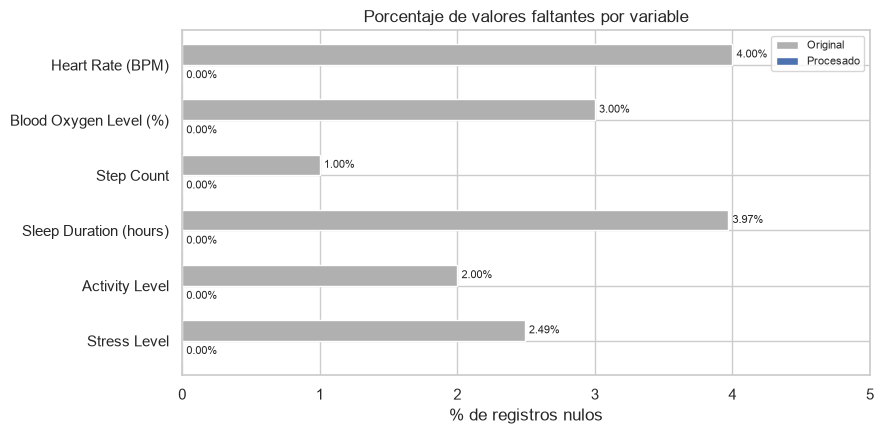

,Original,Procesado
Heart Rate (BPM),4.00,0.0
Blood Oxygen Level (%),3.00,0.0
Step Count,1.00,0.0
Sleep Duration (hours),3.97,0.0
Activity Level,2.00,0.0
Stress Level,2.49,0.0


In [232]:
fig, ax_nulos = plt.subplots(figsize=(9, 4.5))

comparacion_nulos = pd.DataFrame({
    "Original": df_sel.isna().mean() * 100,
    "Procesado": df_limpio.isna().mean() * 100,
})

comparacion_nulos.plot(kind="barh", ax=ax_nulos, color=["#b0b0b0", "#4c72b0"],
                       width=0.75)

# Las barras procesadas valen 0 y no tienen largo visible: se etiquetan ambas
# series para que el cero quede explicito y no parezca un dato ausente.
for contenedor in ax_nulos.containers:
    ax_nulos.bar_label(contenedor, fmt="%.2f%%", padding=3, fontsize=8)

ax_nulos.set_title("Porcentaje de valores faltantes por variable")
ax_nulos.set_xlabel("% de registros nulos")
ax_nulos.set_xlim(0, comparacion_nulos["Original"].max() * 1.25)
ax_nulos.invert_yaxis()
ax_nulos.legend(fontsize=8)

plt.tight_layout()
plt.show()

comparacion_nulos.round(2)

### Resumen numérico del cambio

La tabla cierra la comparación con los estadísticos de cada variable antes y después del
procesamiento, junto con la diferencia entre ambos.

In [231]:
def estadisticos(datos, etiqueta):
    """Resume cada variable numerica en un conjunto de datos."""
    resumen = pd.DataFrame({
        "nulos": datos[COLUMNAS_NUMERICAS].isna().sum(),
        "media": datos[COLUMNAS_NUMERICAS].mean().round(2),
        "mediana": datos[COLUMNAS_NUMERICAS].median().round(2),
        "desv_est": datos[COLUMNAS_NUMERICAS].std().round(2),
        "minimo": datos[COLUMNAS_NUMERICAS].min().round(2),
        "maximo": datos[COLUMNAS_NUMERICAS].max().round(2),
    })
    resumen.columns = pd.MultiIndex.from_product([[etiqueta], resumen.columns])
    return resumen


comparacion = pd.concat(
    [estadisticos(df_sel, "Original"), estadisticos(df_limpio, "Procesado")],
    axis=1,
)

comparacion[("Diferencia", "media")] = (
    comparacion[("Procesado", "media")] - comparacion[("Original", "media")]
).round(2)
comparacion[("Diferencia", "maximo")] = (
    comparacion[("Procesado", "maximo")] - comparacion[("Original", "maximo")]
).round(2)

comparacion

Original                                              \
                          nulos    media  mediana desv_est minimo    maximo   
Heart Rate (BPM)            400    76.04    75.22    19.41  40.00    296.59   
Blood Oxygen Level (%)      300    97.84    98.01     1.73  90.79    100.00   
Step Count                  100  6985.69  4962.53  6885.81   0.91  62486.69   
Sleep Duration (hours)      397     6.51     6.50     1.51  -0.19     12.14   
Stress Level                249     5.46     5.00     2.87   1.00     10.00   

                       Procesado                                              \
                           nulos    media  mediana desv_est minimo    maximo   
Heart Rate (BPM)               0    75.43    75.27    14.07  40.12    130.31   
Blood Oxygen Level (%)         0    97.85    98.01     1.71  90.79    100.00   
Step Count                     0  6965.45  4962.53  6854.25   0.91  62486.69   
Sleep Duration (hours)         0     6.51     6.50     1.48   0.59     12.14   
Stress Level                   0     5.45     5.00     2.84   1.00     10.00   

                       Diferencia          
                            media  maximo  
Heart Rate (BPM)            -0.61 -166.28  
Blood Oxygen Level (%)       0.01    0.00  
Step Count                 -20.24    0.00  
Sleep Duration (hours)       0.00    0.00  
Stress Level                -0.01    0.00

**Lectura de la comparación**

- Los nulos pasan de estar presentes en las seis variables a **cero**, sin haber
  eliminado ninguna fila.
- `Heart Rate (BPM)` es la variable que más cambia: su máximo cae de 296,6 a un valor
  fisiológicamente posible y su media baja, al retirarse los 50 registros imposibles y
  los 84 centinela.
- `Sleep Duration (hours)` pierde su valor negativo, con lo que su mínimo vuelve a un
  rango coherente.
- `Blood Oxygen Level (%)` y `Step Count` mantienen media, mínimo y máximo prácticamente
  intactos: sus atípicos se retuvieron, y la comparación lo confirma visualmente.
- `Activity Level` reduce sus seis etiquetas a tres sin perder registros: las frecuencias
  de las variantes mal escritas se suman a la categoría correcta.

---

# Conclusiones

El conjunto de datos original contenía **10.000 registros y 7 columnas** con cuatro
problemas de calidad bien diferenciados, que este trabajo abordó de forma secuencial.

**Problemas detectados y decisiones adoptadas**

| Problema | Evidencia | Decisión |
| --- | --- | --- |
| Tipos de datos incorrectos | `Sleep Duration` y `Stress Level` se leyeron como texto por los literales `"ERROR"` (247) y `"Very High"` (49). | Conversión con `errors="coerce"`, que aisló esos casos como faltantes. |
| Categorías inconsistentes | `Activity Level` presentaba 6 etiquetas para 3 niveles reales. | Unificación por diccionario de equivalencias antes de imputar. |
| Valores faltantes | Entre 1,0% y 4,0% por columna, en las 7 variables. | Imputación por mediana (continuas y ordinal) y moda (categórica), en lugar de eliminar registros. |
| Valores atípicos | 134 mediciones de pulso imposibles o centinela y 1 duración de sueño negativa. | Se marcaron como faltantes y se imputaron; los extremos plausibles se retuvieron. |

**Características finales**

De las 7 columnas iniciales se descartó únicamente `User ID`, por tratarse de un
identificador sin valor predictivo. El análisis de correlación no reveló redundancia
entre las 6 restantes —ningún par supera 0,8—, por lo que todas se conservaron.

**Estado del dataset**

El resultado son **10.000 registros y 6 variables sin valores faltantes**, con la
variable categórica codificada ordinalmente y todas las escalas homogeneizadas. El
archivo `smartwatch_health_data_model.csv` queda en condiciones de ser utilizado
directamente en la etapa de modelado, mientras que `smartwatch_health_data_clean.csv`
conserva las unidades originales para el análisis descriptivo.

**Observación final**

La ausencia casi total de correlación entre las variables es consistente con el carácter
simulado del conjunto de datos. Un dataset real de smartwatch mostraría dependencias
esperables —por ejemplo, entre el nivel de actividad y el conteo de pasos—, lo que
limita el alcance interpretativo de este análisis, aunque no el del procedimiento de
limpieza aplicado.